# Loading in the data

In [1]:
from tara_preprocessing import full_preprocessing,make_rbf_correlation_matrix,get_just_ecog_data,get_electrode_normalized_loc,make_patient_correlation_matrix
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
import torch
import torch.nn.utils.parametrize as parametrize
import geoopt

In [2]:
data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)
print('Downloaded data')
xyz_clean, mapping_clean, kept_global_indices, cleaned = full_preprocessing(ecogs,xyz)
print('Data cleaned')
patient_corr_mat = make_patient_correlation_matrix(xyz_clean,cleaned,mapping_clean)
print('Got Correlation Matrices, done!')

[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

In [3]:
from noad_production_funcs import create_u
U_det, loss = create_u(k=10,r=100,lamb=1,patient_corr_mat=patient_corr_mat,xyz_clean=xyz_clean)

Optimizing U


100%|██████████| 1000/1000 [00:02<00:00, 352.72it/s]


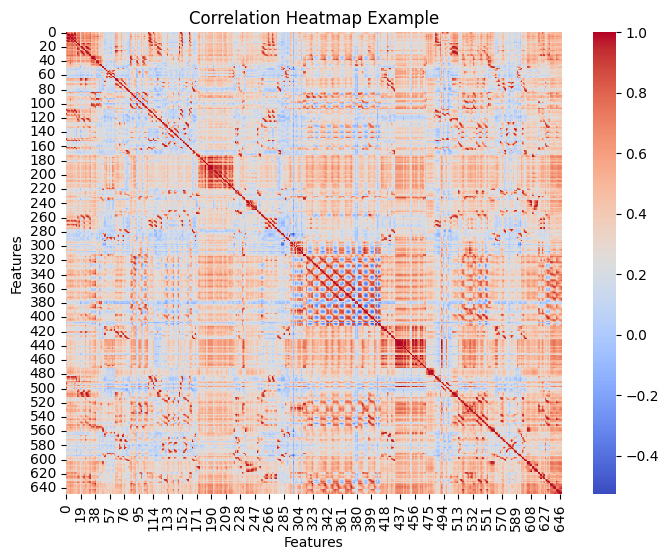

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(U_det@U_det.T, cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

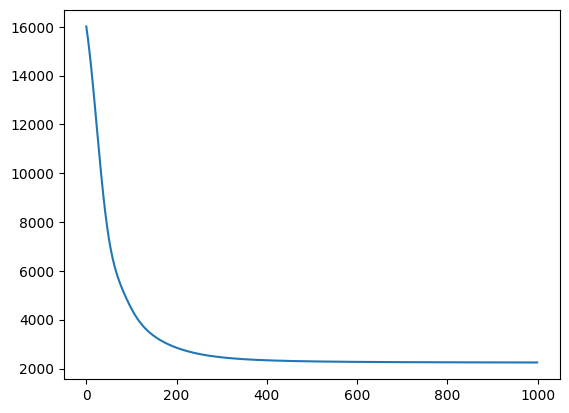

In [17]:
plt.plot(loss)

In [18]:
np.diag(U_det@U_det.T)

array([1.        , 0.9999999 , 1.0000001 , 1.        , 1.        ,
       1.0000001 , 1.0000002 , 1.0000001 , 0.99999994, 1.0000001 ,
       1.0000001 , 0.99999994, 1.        , 1.0000004 , 1.0000001 ,
       1.0000001 , 0.9999999 , 0.99999994, 1.        , 1.0000001 ,
       1.0000002 , 0.99999994, 1.0000001 , 1.0000001 , 1.0000001 ,
       0.99999994, 1.        , 1.0000001 , 1.0000002 , 1.        ,
       1.0000001 , 0.99999994, 0.9999999 , 1.0000001 , 1.0000002 ,
       1.0000004 , 0.99999994, 1.0000001 , 1.0000004 , 1.        ,
       0.99999976, 1.0000001 , 0.9999998 , 1.0000004 , 1.0000002 ,
       1.        , 1.0000004 , 1.0000002 , 1.0000001 , 1.0000001 ,
       1.0000001 , 1.0000002 , 1.0000001 , 1.0000002 , 0.99999994,
       1.0000001 , 1.        , 1.0000002 , 0.9999998 , 0.9999999 ,
       0.9999998 , 0.99999994, 0.99999994, 1.0000001 , 1.        ,
       0.9999999 , 1.0000002 , 0.9999999 , 1.        , 1.0000001 ,
       0.9999997 , 1.0000002 , 0.99999976, 1.        , 1.00000

In [11]:
def object_func(C,U,L,lamb,patient_node_num):
    sum = torch.zeros(1,requires_grad=True) 
    iter = 0
    for i in range(14):
        c = C[i] #each patient correlation matrix
        num_nodes = patient_node_num[i]
        u = U[iter:iter+num_nodes] #all columns of rows iter+num of nodes + 1 
        #print(len(u[:,0]))


        ut = torch.empty((100,len(u)))
        iter = 0
        for row in u:
            ut[:,iter] = row
        ######## Compute u@u.T
        print("ut.shape")
        print(ut.shape)
        print(ut)
        #TODO: 
        #TODO: 
        #TODO: Investage whether you can copy things around and get around the constrain anonying stuff
        #TODO: 
        #TODO: 

        sum = sum + (torch.linalg.norm((u@u.T - c),ord='fro'))**2 #+lamb*torch.trace(U.T@L@U)
        iter = iter + num_nodes
    sum = sum + lamb*torch.trace(U.T@L@U)
    return sum


def create_u(k,r,lamb,patient_corr_mat,xyz_clean,object_func):
    ############## Make Graph ##############
    num_nodes = xyz_clean.shape[0] #649
    neigh = NearestNeighbors(n_neighbors=k).fit(xyz_clean)
    indicesofneigh = neigh.kneighbors()[1] #gets the indices of the 10 (or k) neighbors of each node
    # turn indices lists into pairwiase combos
    all_edges = []
    iter = 0
    for indexs in indicesofneigh:
        for num in indexs:
            all_edges.append((iter,num))
        iter += 1
    G = nx.Graph()
    nodes = np.arange(num_nodes)
    G.add_nodes_from(nodes)
    G.add_edges_from(all_edges)
    ############## Preparing function inputs ##############
    Glaplacian = nx.linalg.laplacian_matrix(G).toarray()
    L = torch.tensor(Glaplacian,dtype=torch.float32,requires_grad=False)
    #r = 200
    #lamb = 1
    patient_node_num = []
    C = []
    for corr in patient_corr_mat:
        C.append(torch.tensor(np.array(corr),requires_grad=True))
        patient_node_num.append(corr.shape[0])
    ############## Preparing U and its manifold ##############
    rng = np.random.default_rng()
    sphere = geoopt.manifolds.Sphere()
    U = []
    for i in range(num_nodes): #for each row in the U matrix
        U_intial = rng.uniform(1,2,(1,r)) #random values to start with
        U_intial = U_intial/np.linalg.norm(U_intial,axis=1,keepdims=True) #ensuring intial U row is normalized
        U_tensor = torch.tensor(U_intial,dtype=torch.float32) 
        U.append(geoopt.ManifoldParameter(U_tensor,manifold=sphere))

    ############## Training U ##############
    optimizer = geoopt.optim.RiemannianAdam(U, lr=0.01)
    loss_list = []
    grads = []
    print("Optimizing U")
    for step in tqdm(range(1000)):
        optimizer.zero_grad()
        z = object_func(C,U,L,lamb,patient_node_num) #this is our loss function
        loss_list.append(z.detach())
        z.backward()
        optimizer.step()
    return U.detach()

In [12]:
U_det = create_u(k=10,r=100,lamb=1,patient_corr_mat=patient_corr_mat,xyz_clean=xyz_clean,object_func=object_func)

Optimizing U


  0%|          | 0/1000 [00:00<?, ?it/s]

ut.shape
torch.Size([100, 44])
tensor([[ 6.8353e-02,  0.0000e+00, -1.5048e-21,  ...,  1.6932e+00,
         -1.2910e-37,  1.7036e+00],
        [ 1.0782e-01,  1.7086e+00,  2.8232e-09,  ...,  1.6956e+00,
          1.6874e-24,  1.6944e+00],
        [ 6.8008e-02,  1.6920e+00, -1.1822e+09,  ...,  1.6304e+00,
         -2.6785e+21,  1.5645e+00],
        ...,
        [ 1.2301e-01,  1.7757e+00,  7.5760e-04,  ...,  1.6470e+00,
          3.3856e-25,  1.7142e+00],
        [ 9.9707e-02,  1.7199e+00,  3.4049e+34,  ...,  1.6622e+00,
         -9.0911e+34,  1.7420e+00],
        [ 7.1284e-02,  1.7369e+00,  1.5972e-12,  ...,  1.7552e+00,
          6.6389e-37,  1.7564e+00]], grad_fn=<CopySlices>)


AttributeError: 'list' object has no attribute 'T'

In [85]:
print("Norm of a Column:")
print(torch.linalg.norm(U_det[1,:]))
print("Norm of a Row:")
print(torch.linalg.norm(U_det[1]))

Norm of a Column:
tensor(1.)
Norm of a Row:
tensor(1.)


In [ ]:
r=100
rng = np.random.default_rng()
U_intial = rng.uniform(1,2,(2,r)) #random values to start with
U_intial = U_intial/np.linalg.norm(U_intial,axis=1,keepdims=True) #ensuring intial U is normalized
U_tensor = torch.tensor(U_intial,dtype=torch.float32) 
#print(U_tensor)
U = torch.empty((2,r))    
with torch.no_grad():
    U[0] = geoopt.ManifoldParameter(U_tensor[0],manifold=geoopt.Sphere())
    U[1] = geoopt.ManifoldParameter(U_tensor[1],manifold=geoopt.Sphere())
U.requires_grad = True
U = U + torch.ones((2,r))    
#print(U.grad_fn)


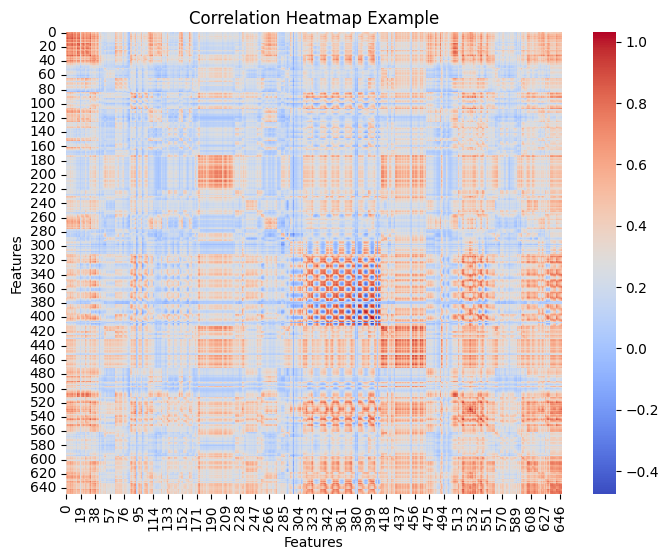

In [65]:
plt.figure(figsize=(8, 6))
sns.heatmap(U_det@U_det.T, cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()